In [12]:
#%%
import sys
import os

from pyfmreader.ps_nex.loadpsneximg import loadPSNEXimg, createPSNEXimgcsv
from pyfmreader.ps_nex.loadpsnexMaps import checkMapFileNULL
# from pyfmreader.ps_nex
from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
import matplotlib.pyplot as plt


In [ ]:

# Path to your test JPK file
# JPK_PATH = "/Users/evillz/Github/GUI_dev_YS_LV/src/pyfmreader-dynamo/tests/testfiles/map-data-2021.11.05-17.37.44.432.jpk-force-map"  # <-- Change this to your file
psnex_map_path = "/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71"
psnex_map_file = "/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.46.09.31.tdms"


psnex_map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54'
psnex_map_file = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54/fcurve___2025.05.23_18.28.05.65.tdms'


In [14]:

scanFolder = True

if scanFolder :
    try: 
        checkMapFileNULL(psnex_map_path)
    except:
        pass

# Load the file using your project's loader
first_file, _ = grab_tdms(psnex_map_path)

print (f'Analyzing TDMS file : {first_file}')

UFF = loadfile(first_file)


#%%
# Debug: print some metadata
# print("File metadata:", UFF.filemetadata)

# system_{ax}_piezo_sensitivity_(nm/V)

x_piezo_sensitivity_nmV = UFF.filemetadata.get('system_X_piezo_sensitivity_(nm/V)')
y_piezo_sensitivity_nmV = UFF.filemetadata.get('system_Y_piezo_sensitivity_(nm/V)')

# Needs to be finilized
UFF.filemetadata['isFV'] = True
UFF.filemetadata['num_x_pixels'] = 32
UFF.filemetadata['num_y_pixels'] = 32
# UFF.filemetadata['scan_size_x_um'] = x_piezo_sensitivity_nmV * 1e-03 * (UFF.filemetadata['num_x_pixels']-1)
# UFF.filemetadata['scan_size_y_um'] = y_piezo_sensitivity_nmV * UFF.filemetadata['num_y_pixels']
UFF.filemetadata['scan_size_x_um'] = 0
UFF.filemetadata['scan_size_y_um'] = 0
# #%%
# #%%
# # Call the function and print results
piezoImage, data = loadPSNEXimg(UFF)
# csv_file_path, data = createPSNEXimgcsv(UFF)
print (piezoImage.shape)
# data

print("Loaded channels:", list(data.keys()))
for channel, img in data.items():
    print(f"Channel: {channel}, shape: {img.shape}, dtype: {img.dtype}")
print("Piezo image shape:", piezoImage.shape)


processing file : /Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54
segment duration 15.944253999999999, 
 numb of point cal (ticks, dec, sampling rate 9965, num pts stored per segment 99651
segment duration 42.703759999999996, 
 numb of point cal (ticks, dec, sampling rate 26689, num pts stored per segment 266897
df_point log made
segment duration 17.987562, 
 numb of point cal (ticks, dec, sampling rate 11242, num pts stored per segment 112421
segment duration 37.18262, 
 numb of point cal (ticks, dec, sampling rate 23239, num pts stored per segment 232390
df_point log made
segment duration 18.05145, 
 numb of point cal (ticks, dec, sampling rate 11282, num pts stored per segment 112820
segment duration 37.20568, 
 numb of point cal (ticks, dec, sampling rate 23253, num pts stored per segment 232534
df_point log made
segment duration 17.668748, 
 numb of point cal (ticks, dec, sampling rate 11042, num pts stored per segment 110428
segment duration 36.98218, 
 n

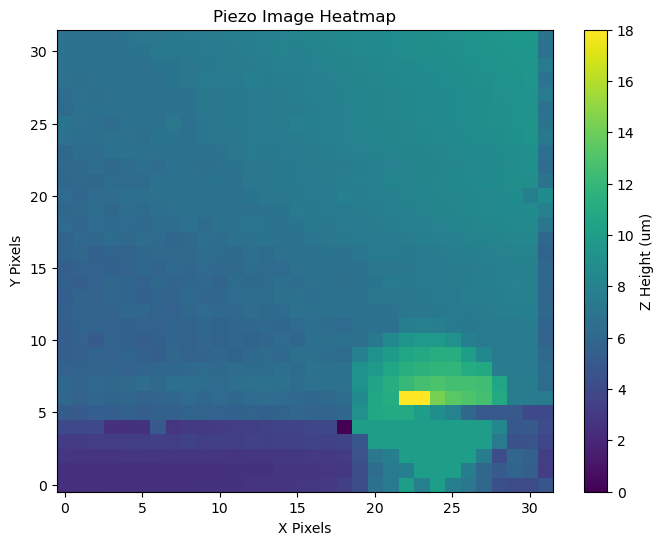

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(piezoImage, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='Z Height (um)')
plt.title('Piezo Image Heatmap')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show(block=True)